<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/05_2_%EA%B7%B8%EB%A6%AC%EB%93%9C_%EC%84%9C%EC%B9%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


- **그리드 서치**(grid search): 관심 있는 매개변수들을 대상으로 간으한 모든 조합을 시도

## 01 간단한 그리드 서치

In [3]:
# RBF 커널 SVM의 매개 변수 gamma, C의 최적 값 찾기
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target,
                                                    random_state=0)
print(f"훈련 세트의 크기: {X_train.shape[0]}, 테스트 세트의 크기: {X_test.shape[0]}")

best_score = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
  for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    svm = SVC(gamma=gamma, C=C)
    svm.fit(X_train, y_train)
    score = svm.score(X_test, y_test)
    if score > best_score:
      best_score = score
      best_parameters = {"C": C, "gamma": gamma}

print(f"최고 점수: {round(best_score, 2)}")
print(f"최적 매개변수: {best_parameters}")

훈련 세트의 크기: 112, 테스트 세트의 크기: 38
최고 점수: 0.97
최적 매개변수: {'C': 100, 'gamma': 0.001}


## 02 매개변수 과대적합과 검증 세트
- 문제점: 매개변수를 조정하기 위해 테스트 세트를 이미 사용했기 때문에 모델이 얼마나 좋은지 평가하는 데는 더 이상 사용할 수 없음 ➡️ 평가를 위해서는 모델을 만들 때 사용하지 않은 독립된 데이터셋이 필요
- 훈련 세트: 모델 개발
- **검증 세트**: 모델의 매개변수 선택
- 테스트 세트: 선택된 매개변수의 성능 평가
- ✨ 검증 세트를 사용해 최적의 매개변수를 선택한 후, 그 매개변수에서 훈련 세트와 검증 세트 데이터를 모두 이용해 모델을 다시 만듦

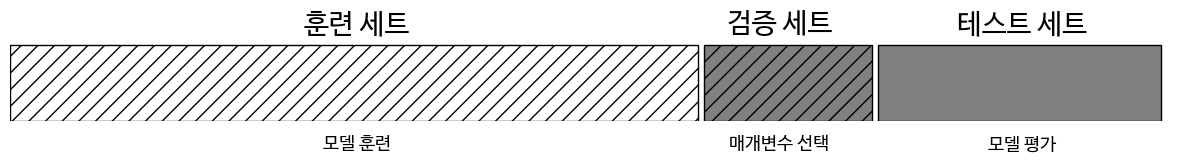

In [4]:
# 훈련 세트, 검증 세트, 테스트 세트의 3개 폴드로 나눈 데이터
mglearn.plots.plot_threefold_split()

In [6]:
from sklearn.svm import SVC

# 훈련+검증 세트 / 테스트 세트
X_trainval, X_test, y_trainval, y_test = train_test_split(
    iris.data, iris.target, random_state=0
)

# 훈련+검증 세트 -> 훈련 세트 / 검증 세트
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, random_state=1
)

print(f"훈련 세트의 크기: {X_train.shape[0]}, 검증 세트의 크기: {X_valid.shape[0]},\
      테스트 세트의 크기: {X_test.shape[0]}")

best_scre = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
  for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    svm = SVC(gamma=gamma, C=C)
    svm.fit(X_train, y_train)
    score = svm.score(X_valid, y_valid) # 검증 세트로 SVC 평가
    if score > best_score:
      best_score = score
      best_parameters = {"C": C, "gamma": gamma}

# 훈련 세트와 검증 세트를 합쳐 모델을 다시 만든 후 테스트 세트를 사용해 평가
svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)
test_score = svm.score(X_test, y_test)
print(f"검증 세트에서 최고 점수: {round(best_score, 2)}")
print(f"최적 매개변수: {best_parameters}")
print(f"최적 매개변수에서 테스트 세트 점수: {round(test_score, 2)}")

훈련 세트의 크기: 84, 검증 세트의 크기: 28,      테스트 세트의 크기: 38
검증 세트에서 최고 점수: 0.97
최적 매개변수: {'C': 100, 'gamma': 0.001}
최적 매개변수에서 테스트 세트 점수: 0.97


- ✨✨ **최종 평가에만 사용하도록 테스트 세트를 분리해 유지하는 것이 중요!**
- 모든 EDA와 모델 선택을 위해서는 훈련 세트와 검증 세트를 사용하는 것을 권장하며, 마지막 평가를 위해 테스트 세트를 보관하는 것이 좋음
- 테스트 세트로 둘 이상의 모델을 평가하여 그중 더 나은 하나를 선택하는 것은 모델의 정확도를 매우 낙관적으로 추정하는 행위

## 03 교차 검증을 사용한 그리드 서치

In [8]:
# 교차 검증을 사용해 매개변수 조합의 성능을 평가
from sklearn.model_selection import cross_val_score

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
  for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    svm = SVC(gamma=gamma, C=C)
    scores = cross_val_score(svm, X_trainval, y_trainval, cv=5)
    score = np.mean(scores)
    if score > best_score:
      best_score = score
      best_parameters = {"C": C, "gamma": gamma}

svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)

SVC(C=100, gamma=0.001)

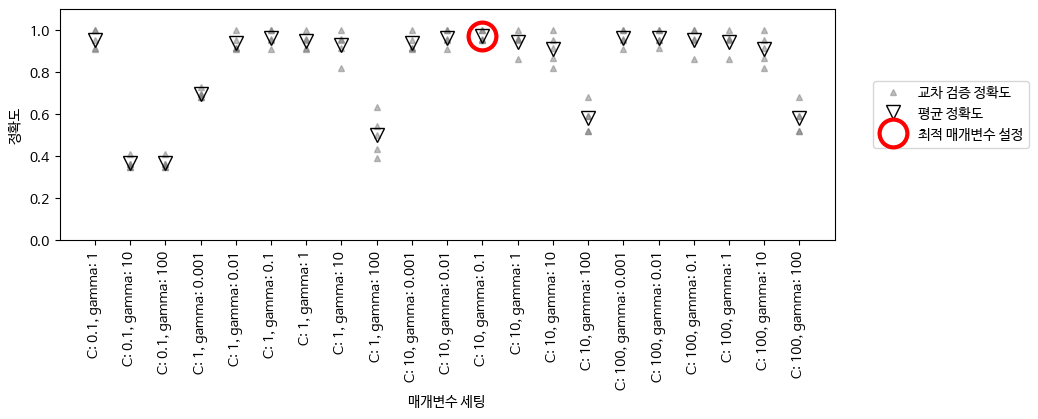

In [9]:
# 교차 검증을 사용한 그리드 서치의 결과
mglearn.plots.plot_cross_val_selection()

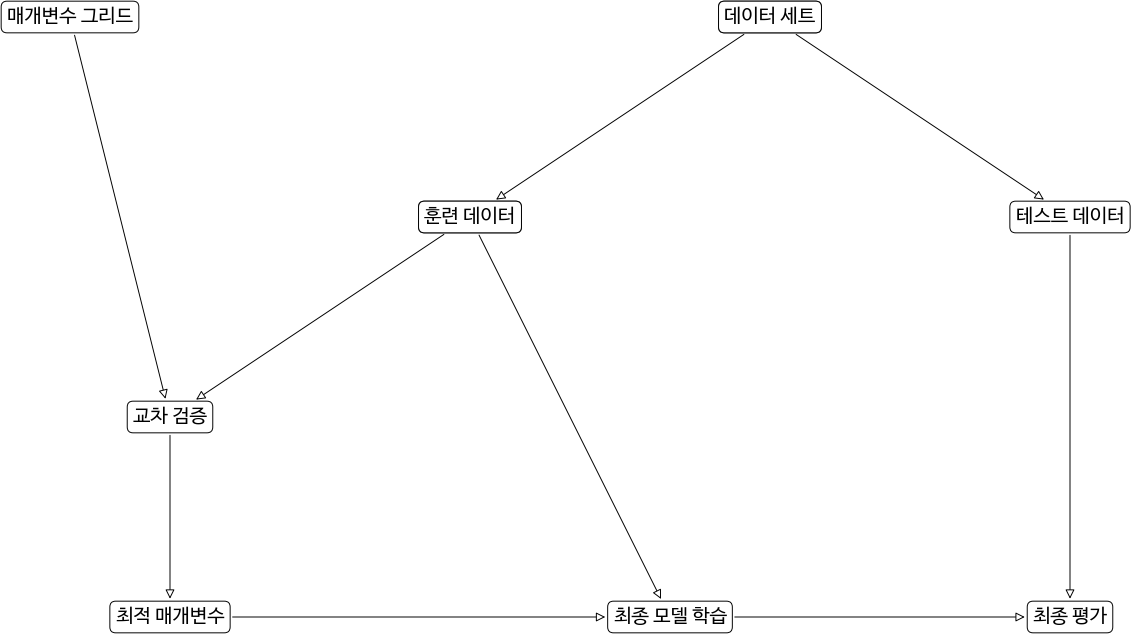

In [10]:
# 교차 검증과 그리드 서치를 사용한 매개변수 선택과 모델 평가의 작업 흐름
mglearn.plots.plot_grid_search_overview()

- `GridSearchCV()`
  - 딕셔너리 형태로 검색 대상 매개변수 지정
    - key: 조정하고자 하는 매개변수 이름
    - value: 탐색할 매개변수의 설정값
  - `GridSearchCV()`는 필요한 모든 모델을 학습함

In [11]:
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100],
              "gamma": [0.001, 0.01, 0.1, 1, 10, 100]}
print(f"매개변수 그리드:\n{param_grid}")

매개변수 그리드:
{'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}


In [12]:
from sklearn.model_selection import GridSearchCV

# 5-겹 계층별 교차 검증: 기본값은 분류에서 StraitifiedKFold, 회귀에서 KFold
grid_search = GridSearchCV(SVC(), param_grid, cv=5, return_train_score=True)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target,
                                                    random_state=0)

In [15]:
# 교차 검증 성능이 가장 좋은 매개변수 조합으로 전체 훈련 데이터셋에 대해 새로운 모델을 자동으로 만듦
# ln[8]과 동일한 코드
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'gamma': [0.001, 0.01, 0.1, 1, 10, 100]},
             return_train_score=True)

In [18]:
# 일반화 성능 평가
print(f"테스트 세트 점수: {round(grid_search.score(X_test, y_test), 2)}")

테스트 세트 점수: 0.97


In [19]:
print(f"최적 매개변수: {grid_search.best_params_}")
print(f"최고 교차 검증 점수: {round(grid_search.best_score_, 2)}")

최적 매개변수: {'C': 10, 'gamma': 0.1}
최고 교차 검증 점수: 0.97


In [20]:
print(f"최고 성능 모델:\n{grid_search.best_estimator_}")

최고 성능 모델:
SVC(C=10, gamma=0.1)


### 3.1 교차 검증 결과 분석
- 그리드 서치는 연산 비용이 매우 크므로 비교적 간격을 넓게 하여 적은 수의 그리드로 시작하는 것이 좋음
- 그 다음 교차 검증된 그리드 서치의 결과를 분석하여 검색을 확장
- 그리드 서치의 결과는 `cv_results_` 속성에 저장

In [22]:
import pandas as pd

pd.set_option("display.max_columns", None)
results = pd.DataFrame(grid_search.cv_results_)
np.transpose(results.head())

,0,1,2,3,4
mean_fit_time,0.0,0.0,0.0,0.0,0.0
std_fit_time,0.0,0.0,0.0,0.0,0.0
mean_score_time,0.0,0.0,0.0,0.0,0.0
std_score_time,0.0,0.0,0.0,0.0,0.0
param_C,0.0,0.0,0.0,0.0,0.0
param_gamma,0.0,0.01,0.1,1.0,10.0
params,"{'C': 0.001, 'gamma': 0.001}","{'C': 0.001, 'gamma': 0.01}","{'C': 0.001, 'gamma': 0.1}","{'C': 0.001, 'gamma': 1}","{'C': 0.001, 'gamma': 10}"
split0_test_score,0.35,0.35,0.35,0.35,0.35
split1_test_score,0.35,0.35,0.35,0.35,0.35
split2_test_score,0.36,0.36,0.36,0.36,0.36


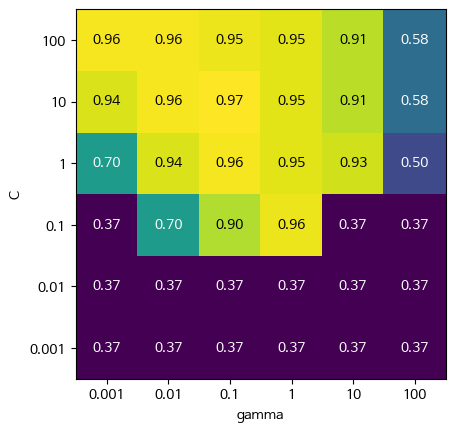

In [23]:
# C와 gamma 값에 따른 교차 검증 평균 점수의 히트맵

scores = np.array(results.mean_test_score).reshape(6, 6)

mglearn.tools.heatmap(scores, xlabel="gamma", xticklabels=param_grid["gamma"],
                      ylabel="C", yticklabels=param_grid["C"], cmap="viridis")

- 높은 성능을 얻으려면 매개변수 조정이 매우 중요
- 각 매개변수의 최적값이 그래프 끝에 놓이지 않도록 매개변수의 범위가 충분히 넓어야 함

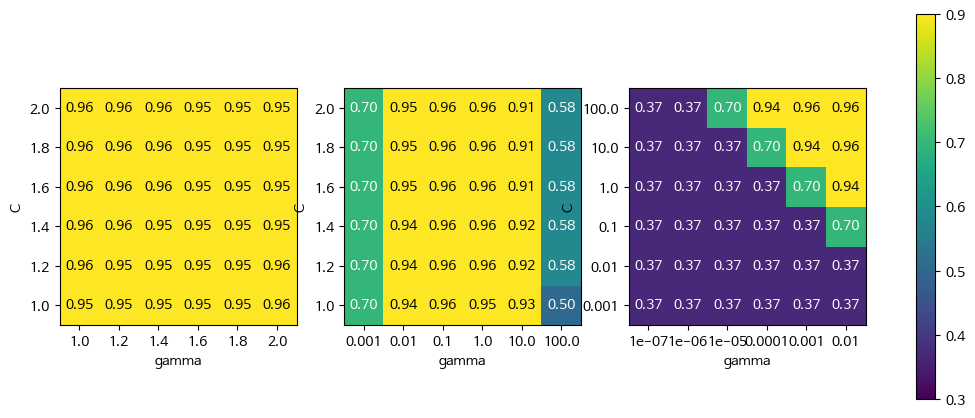

In [24]:
# 검색 범위가 적절하지 않은 매개변수 그리드의 히트맵

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

param_grid_linear = {"C": np.linspace(1, 2, 6),
                     "gamma": np.linspace(1, 2, 6)}

param_grid_one_log = {"C": np.linspace(1, 2, 6),
                      "gamma": np.logspace(-3, 2, 6)}

param_grid_range = {"C": np.logspace(-3, 2, 6),
                    "gamma": np.logspace(-7, -2, 6)}

for param_grid, ax in zip([param_grid_linear, param_grid_one_log, param_grid_range], axes):
  grid_search = GridSearchCV(SVC(), param_grid, cv=5)
  grid_search.fit(X_train, y_train)
  scores = grid_search.cv_results_["mean_test_score"].reshape(6, 6)

  scores_image = mglearn.tools.heatmap(
      scores, xlabel="gamma", ylabel="C", xticklabels=param_grid["gamma"],
      yticklabels=param_grid["C"], cmap="viridis", ax=ax, vmin=0.3, vmax=0.9
  )

plt.colorbar(scores_image, ax=axes.tolist())

- 첫 번째 그래프
  - 파라미터의 스케일과 범위가 부적절할 때
  - 매개변수 설정이 바뀌어도 정확도에 변화가 없다면, 그 매개변수가 전혀 중요하지 않은 것일 수 있음 ➡️ 처음에는 매우 극단적인 값을 적용해보고, 매개변수를 바꿔가며 정확도가 변하는지 살펴보기
- 두 번째 그래프
  - 세로 띠 형태
  - `gamma` 매개변수만 정확도에 영향을 준다는 뜻
  - `gamma` 매개변수는 적절한 범위를 탐색하고 있지만, `C` 매개변수는 그렇지 못하든지, 아니면 중요한 매개변수가 아닐 수도 있음
- 세 번째 그래프
  - 그래프의 왼쪽 아래 영역에서는 변화가 없음
  - 다음 번 검색 땐 매개변수 그리드에서 매우 작은 단위는 제외
  - 더 큰 값의 영역이 포함되도록 매개변수 검색 범위를 바꿔주기
- ✨✨ **최종 테스트 세트를 대상으로 여러 매개변수 범위를 테스트해서는 안 됨!!!!**

### 3.2 비대칭 매개변수 그리드 탐색
- `SVC`의 `kernel` 매개변수
  - `kernel="linear"`: 선형모델, 매개변수 `C`만 사용
  - `kernel="rbf"`: `C`와 `gamma` 모두 사용
- 조건부 매개변수 조합을 적용하기 위해서는 `param_grid`를 딕셔너리의 리스트로 만들기

In [25]:
param_grid = [{"kernel": ["rbf"],
               "C": [0.001, 0.01, 0.1, 1, 10, 100],
               "gamma": [0.001, 0.01, 0.1, 1, 10, 100]},
              {"kernel": ["linear"],
               "C": [0.001, 0.01, 0.1, 1, 10, 100]
               }]
print(f"그리드 목록:\n{param_grid}")

그리드 목록:
[{'kernel': ['rbf'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}, {'kernel': ['linear'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]}]


In [26]:
grid_search = GridSearchCV(SVC(), param_grid, cv=5, return_train_score=True)
grid_search.fit(X_train, y_train)
print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최고 교차 검증 점수: {round(grid_search.best_score_, 2)}")

최적 파라미터: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
최고 교차 검증 점수: 0.97


In [27]:
results = pd.DataFrame(grid_search.cv_results_)
results.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41
mean_fit_time,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std_fit_time,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean_score_time,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std_score_time,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
param_C,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.01,0.01,0.01,0.01,0.01,0.1,0.1,0.1,0.1,0.1,0.1,1.0,1.0,1.0,1.0,1.0,1.0,10.0,10.0,10.0,10.0,10.0,10.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.01,0.1,1.0,10.0,100.0
param_gamma,0.0,0.01,0.1,1.0,10.0,100.0,0.0,0.01,0.1,1.0,10.0,100.0,0.0,0.01,0.1,1.0,10.0,100.0,0.0,0.01,0.1,1.0,10.0,100.0,0.0,0.01,0.1,1.0,10.0,100.0,0.0,0.01,0.1,1.0,10.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN
param_kernel,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,linear,linear,linear,linear,linear,linear
params,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 1, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 100, 'kernel': 'rbf'}","{'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 1, 'gamma': 1, 'kernel': 'rbf'}","{'C': 1, 'gamma': 10, 'kernel': 'rbf'}","{'C': 1, 'gamma': 100, 'kernel': 'rbf'}","{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 10, 'gamma': 1, 'kernel': 'rbf'}","{'C': 10, 'gamma': 10, 'kernel': 'rbf'}","{'C': 10, 'gamma': 100, 'kernel': 'rbf'}","{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 10, 'kernel': 'rbf'}","{'C': 100, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.001, 'kernel': 'linear'}","{'C': 0.01, 'kernel': 'linear'}","{'C': 0.1, 'kernel': 'linear'}","{'C': 1, 'kernel': 'linear'}","{'C': 10, 'kernel': 'linear'}","{'C': 100, 'kernel': 'linear'}"
split0_test_score,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.7,0.91,1.0,0.35,0.35,0.7,0.91,1.0,0.96,0.91,0.39,0.91,1.0,1.0,0.96,0.87,0.52,1.0,1.0,1.0,0.96,0.87,0.52,0.35,0.87,1.0,1.0,1.0,0.96
split1_test_score,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.7,0.91,0.91,0.35,0.35,0.7,0.91,0.96,0.91,0.96,0.43,0.91,0.96,0.96,0.96,0.91,0.52,0.96,0.91,0.96,0.96,0.91,0.52,0.35,0.87,0.91,0.96,1.0,0.96


### 3.3 그리드 서치에 다양한 교차 검증 적용
- `GridSearchCV` 기본값: 분류에는 계층형 k-겹 교차 검증, 회귀에는 k-겹 교차 검증
- 훈련 세트와 검증 세트로 한 번만 분할하려면 `n_splits=1`로 하고 `ShuffleSplit`나 `StratifiedShuffleSplit`을 사용 (데이터셋이 매우 크거나 모델 구축에 시간이 오래 걸릴 때 유용)

#### 중첩 교차 검증
- `GridSearchCV`는 훈련 세트와 테스트 세트로 한 번만 나누기 때문에, 결과가 불안정하고 테스트 데이터의 분할에 크게 의존
- **중첩 교차 검증**(nested cross-validation) 사용 가능
  - 바깥쪽 루프에서 데이터를 훈련 세트와 테스트 세트로 나눔
  - 각 훈련 세트에 대해 그리드 서치 실행 (훈련 세트마다 최적의 매개변수가 다름)
  - 바깥쪽에서 분할된 테스트 세트의 점수를 최적의 매개변수 설정을 사용해 각각 측정
- 모델이나 매개변수 설정이 아닌 테스트 점수의 목록을 만듦 ➡️ 이 점수들은 최적 매개변수가 모델을 얼마나 잘 일반화시키는지 알려줌
- 새로운 데이터에 적용할 모델을 만드는 것이 아님 ➡️ 예측 모델을 찾는 데는 거의 사용하지 않음
- 특정 데이터셋에서 주어진 모델이 얼마나 잘 일반화되는지 평가하는 데 유용한 방법

In [29]:
# 만들어지는 모델 개수: 36 (매개변수 조합) * 5(계층형 5-겹 교차 검증) * 5(계층형 5-겹 교차 검증)
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100],
              "gamma": [0.001, 0.01, 0.1, 1, 10, 100]}
scores = cross_val_score(GridSearchCV(SVC(), param_grid, cv=5),
                         iris.data, iris.target, cv=5)
print(f"교차 검증 점수: {scores}")
print(f"교차 검증 평균 점수: {round(scores.mean(), 2)}")

교차 검증 점수: [0.967 1.    0.967 0.967 1.   ]
교차 검증 평균 점수: 0.98


In [33]:
# 안쪽과 바깥쪽 루프에 각기 다른 교차 검증 전략

def nested_cv(X, y, inner_cv, outer_cv, Classifier, parameter_grid):
  outer_scores = []
  for training_samples, test_samples in outer_cv.split(X, y):
    best_params = {}
    best_score = -np.inf
    for parameters in parameter_grid:
      cv_scores = []
      for inner_train, inner_test in inner_cv.split(
          X[training_samples], y[training_samples]):
        clf = Classifier(**parameters)
        clf.fit(X[inner_train], y[inner_train])
        score = clf.score(X[inner_test], y[inner_test])
        cv_scores.append(score)
      mean_score = np.mean(cv_scores)
      if mean_score > best_score:
        best_score = mean_score
        best_params = parameters
    clf = Classifier(**best_parameters)
    clf.fit(X[training_samples], y[training_samples])
    outer_scores.append(clf.score(X[test_samples], y[test_samples]))
  return np.array(outer_scores)


In [34]:
from sklearn.model_selection import ParameterGrid, StratifiedKFold

scores = nested_cv(iris.data, iris.target, StratifiedKFold(5),
                   StratifiedKFold(5), SVC, ParameterGrid(param_grid))
print(f"교차 검증 점수: {scores}")

교차 검증 점수: [0.967 1.    0.967 0.967 1.   ]


#### 교차 검증과 그리드 서치 병렬화
- 그리드 서치와 교차 검증은 쉽게 병렬화 가능
- `GridSearchCV`와 `cross_val_score`에서 `n_jobs` 매개변수에 사용할 CPU 코어 수 지정 가능